# Pediatric Medical Conditions Visualization

This notebook visualizes the distribution of medical conditions in the Bridge2AI Voice Pediatric Dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Load the medical conditions data
df = pd.read_csv('phenotype/pediatric/pediatric_medical_conditions.tsv', sep='\t')

print(f"Total records: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names:")
print(df.columns.tolist())

Total records: 305
Number of columns: 50

Column names:
['participant_id', 'peds_mc_a_therapy', 'peds_mc_adenoidectomy', 'peds_mc_allergies', 'peds_mc_breathing_conditions', 'peds_mc_chronic_medical_condition', 'peds_mc_completed_at', 'peds_mc_conditions', 'peds_mc_dif_swallowing', 'peds_mc_duration', 'peds_mc_ear_inf_ant_py', 'peds_mc_epistaxis', 'peds_mc_etp', 'peds_mc_eval_voice_swal_c', 'peds_mc_fr_inf_tons', 'peds_mc_fr_v_f', 'peds_mc_ft', 'peds_mc_genetic_syndromes', 'peds_mc_hearing_loss', 'peds_mc_hl', 'peds_mc_hospitalized', 'peds_mc_hw_voice_2_w', 'peds_mc_l2w', 'peds_mc_lingual_tonsillectomy', 'peds_mc_meds', 'peds_mc_nasal_fractures', 'peds_mc_neck_mass_branchial_cleft_cyst_surgery', 'peds_mc_neck_mass_dermoid_cyst_surgery', 'peds_mc_neck_mass_enlarged_lymph_node_surgery', 'peds_mc_neck_mass_hyroid_nodule_or_cancer_surgery', 'peds_mc_neck_mass_other', 'peds_mc_neck_mass_thyroglossal_duct_cyst_surgery', 'peds_mc_neurological_disorders', 'peds_mc_neurological_disorders_specif

## Yes/No Condition Prevalence

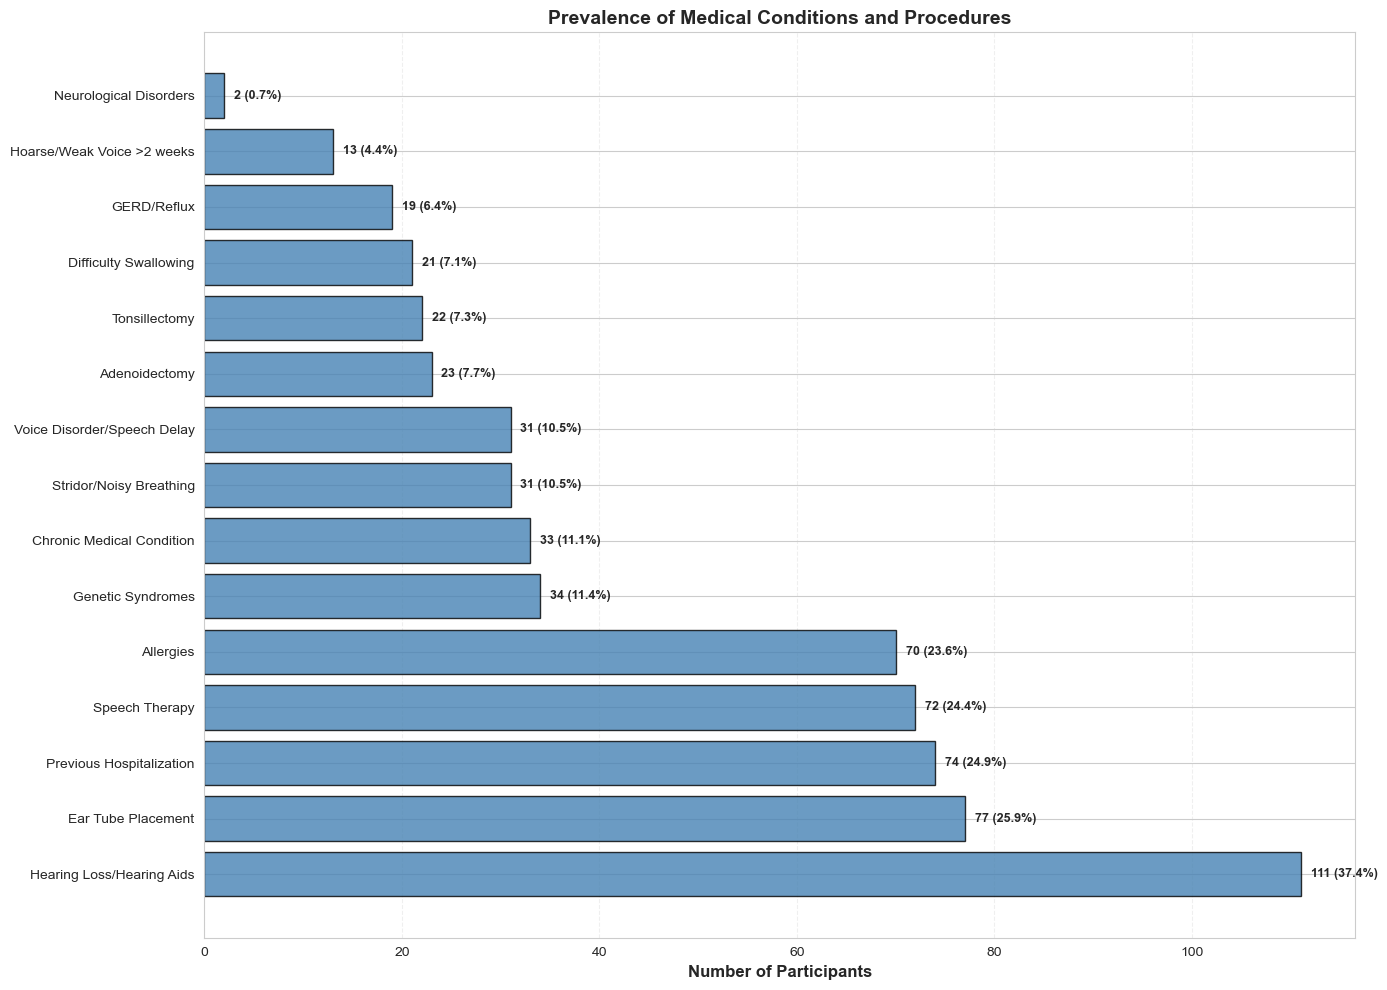

In [3]:
# Key yes/no medical condition columns
yes_no_conditions = {
    'peds_mc_a_therapy': 'Speech Therapy',
    'peds_mc_allergies': 'Allergies',
    'peds_mc_chronic_medical_condition': 'Chronic Medical Condition',
    'peds_mc_dif_swallowing': 'Difficulty Swallowing',
    'peds_mc_hl': 'Hearing Loss/Hearing Aids',
    'peds_mc_hospitalized': 'Previous Hospitalization',
    'peds_mc_hw_voice_2_w': 'Hoarse/Weak Voice >2 weeks',
    'peds_mc_genetic_syndromes': 'Genetic Syndromes',
    'peds_mc_neurological_disorders': 'Neurological Disorders',
    'peds_mc_reflux': 'GERD/Reflux',
    'peds_mc_stridor': 'Stridor/Noisy Breathing',
    'peds_mc_v_dis': 'Voice Disorder/Speech Delay',
    'peds_mc_tonsillectomy': 'Tonsillectomy',
    'peds_mc_adenoidectomy': 'Adenoidectomy',
    'peds_mc_etp': 'Ear Tube Placement',
}

# Calculate percentages
condition_counts = {}
for col, label in yes_no_conditions.items():
    if col in df.columns:
        yes_count = (df[col] == 'Yes').sum()
        total_valid = df[col].notna().sum()
        if total_valid > 0:
            percentage = (yes_count / total_valid) * 100
            condition_counts[label] = {'count': yes_count, 'percentage': percentage}

# Sort by count
sorted_conditions = sorted(condition_counts.items(), key=lambda x: x[1]['count'], reverse=True)

# Create bar plot
plt.figure(figsize=(14, 10))
labels = [item[0] for item in sorted_conditions]
counts = [item[1]['count'] for item in sorted_conditions]
percentages = [item[1]['percentage'] for item in sorted_conditions]

bars = plt.barh(range(len(labels)), counts, color='steelblue', edgecolor='black', alpha=0.8)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Number of Participants', fontsize=12, fontweight='bold')
plt.title('Prevalence of Medical Conditions and Procedures', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    plt.text(count + 1, bar.get_y() + bar.get_height()/2, 
             f'{int(count)} ({pct:.1f}%)', 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Hearing Loss Types

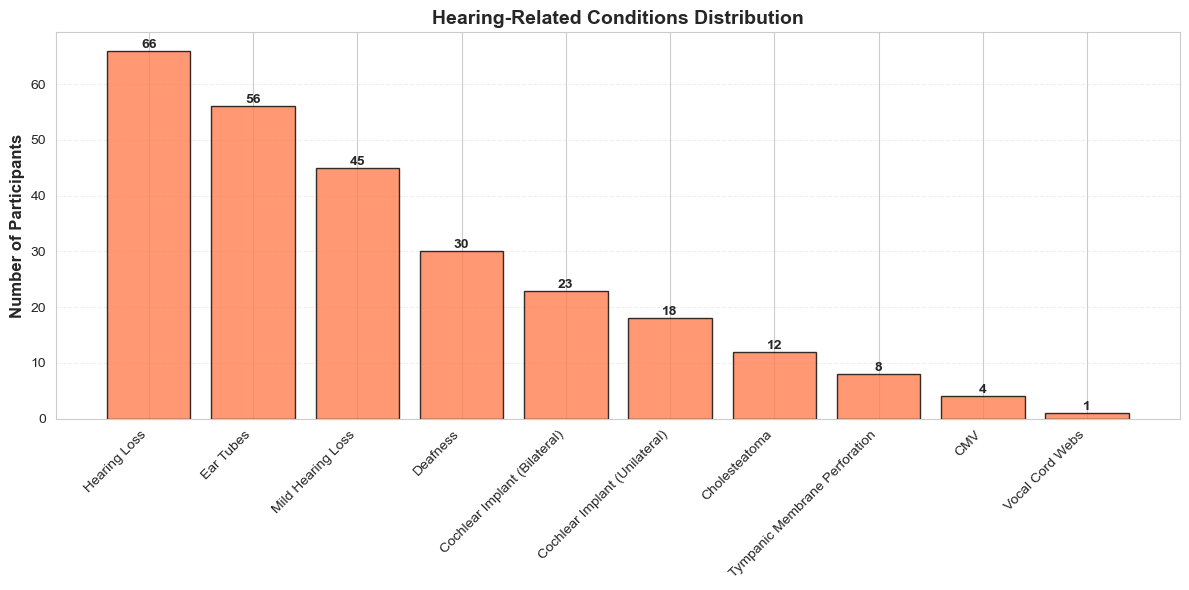

In [4]:
# Parse hearing loss conditions (multi-select field)
hearing_conditions = []
for val in df['peds_mc_hearing_loss'].dropna():
    if isinstance(val, str) and val.strip():
        hearing_conditions.extend([item.strip() for item in val.split(',')])

hearing_counter = Counter(hearing_conditions)

if hearing_counter:
    # Readable labels
    hearing_labels = {
        'hearing loss': 'Hearing Loss',
        'mild hearing loss': 'Mild Hearing Loss',
        'deafness': 'Deafness',
        'cholesteatoma': 'Cholesteatoma',
        'ear tubes': 'Ear Tubes',
        'cochlear implantation bilateral': 'Cochlear Implant (Bilateral)',
        'cochlear implantation unilateral': 'Cochlear Implant (Unilateral)',
        'tympanic membrane perforation': 'Tympanic Membrane Perforation',
        'cmv': 'CMV',
        'vocal cord webs': 'Vocal Cord Webs'
    }
    
    hearing_data = [(hearing_labels.get(k, k.title()), v) for k, v in hearing_counter.most_common()]
    hearing_data = sorted(hearing_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_h = [item[0] for item in hearing_data]
    counts_h = [item[1] for item in hearing_data]
    
    bars = plt.bar(range(len(labels_h)), counts_h, color='coral', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_h)), labels_h, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Hearing-Related Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_h):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No hearing loss data found")

## Breathing and Airway Conditions

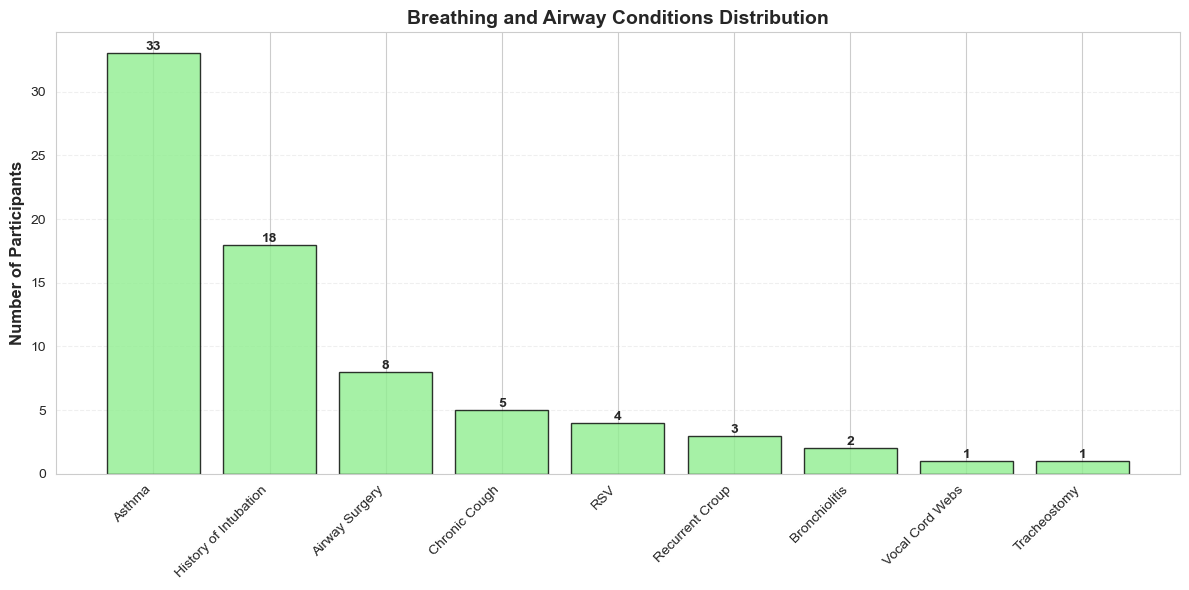

In [5]:
# Parse breathing conditions (multi-select field)
breathing_conditions = []
for val in df['peds_mc_breathing_conditions'].dropna():
    if isinstance(val, str) and val.strip():
        breathing_conditions.extend([item.strip() for item in val.split(',')])

breathing_counter = Counter(breathing_conditions)

if breathing_counter:
    # Readable labels
    breathing_labels = {
        'asthma': 'Asthma',
        'recurrent croup': 'Recurrent Croup',
        'bronchiolitis': 'Bronchiolitis',
        'rsv': 'RSV',
        'chronic cough': 'Chronic Cough',
        'subglottic stenosis': 'Subglottic Stenosis',
        'vocal cord webs': 'Vocal Cord Webs',
        'airway surgery': 'Airway Surgery',
        'intubated': 'History of Intubation',
        'tracheostomy': 'Tracheostomy'
    }
    
    breathing_data = [(breathing_labels.get(k, k.title()), v) for k, v in breathing_counter.most_common()]
    breathing_data = sorted(breathing_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_b = [item[0] for item in breathing_data]
    counts_b = [item[1] for item in breathing_data]
    
    bars = plt.bar(range(len(labels_b)), counts_b, color='lightgreen', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_b)), labels_b, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Breathing and Airway Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_b):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No breathing conditions data found")

## Voice Disorders

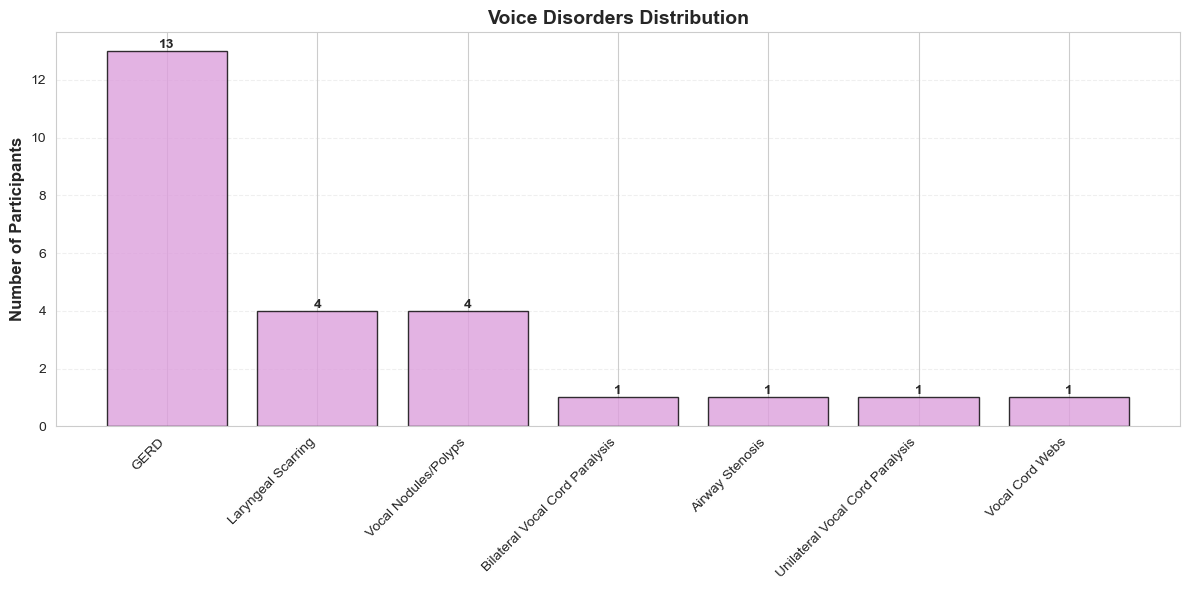

In [6]:
# Parse voice disorders (multi-select field)
voice_disorders = []
for val in df['peds_mc_voice_disorders'].dropna():
    if isinstance(val, str) and val.strip():
        voice_disorders.extend([item.strip() for item in val.split(',')])

voice_counter = Counter(voice_disorders)

if voice_counter:
    # Readable labels
    voice_labels = {
        'vocal nodules or polyps': 'Vocal Nodules/Polyps',
        'unilateral vocal cord paralysis': 'Unilateral Vocal Cord Paralysis',
        'bilateral vocal cord paralysis': 'Bilateral Vocal Cord Paralysis',
        'acid reflux disease': 'GERD',
        'scarring': 'Laryngeal Scarring',
        'airway stenosis': 'Airway Stenosis',
        'vocal cord webs': 'Vocal Cord Webs'
    }
    
    voice_data = [(voice_labels.get(k, k.title()), v) for k, v in voice_counter.most_common()]
    voice_data = sorted(voice_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_v = [item[0] for item in voice_data]
    counts_v = [item[1] for item in voice_data]
    
    bars = plt.bar(range(len(labels_v)), counts_v, color='plum', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_v)), labels_v, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Voice Disorders Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_v):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No voice disorders data found")

## Sleep-Related Conditions

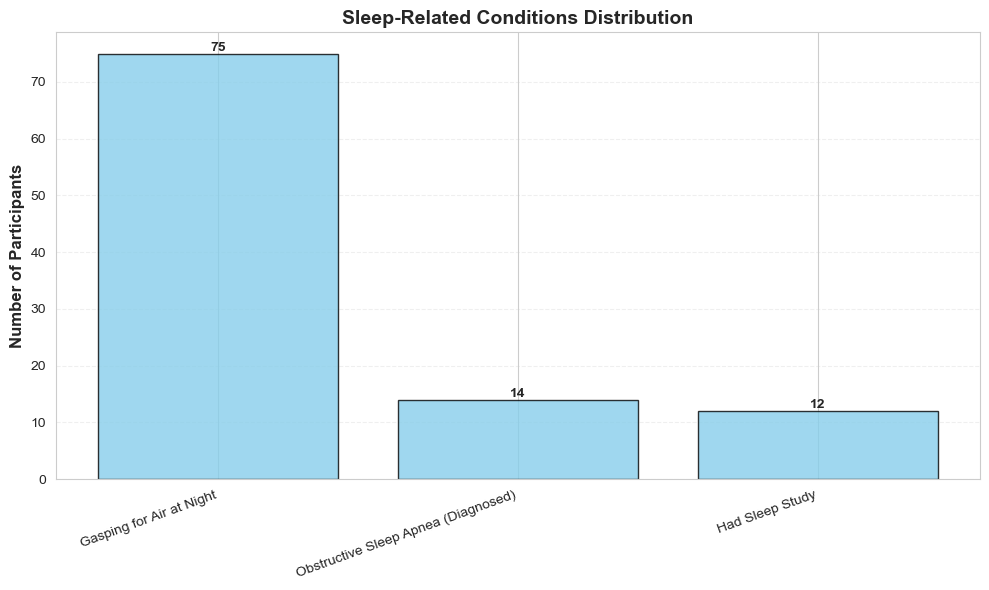

In [7]:
# Parse snoring/apnea conditions (multi-select field)
sleep_conditions = []
for val in df['peds_mc_snoring_apnea'].dropna():
    if isinstance(val, str) and val.strip():
        sleep_conditions.extend([item.strip() for item in val.split(',')])

sleep_counter = Counter(sleep_conditions)

if sleep_counter:
    # Readable labels
    sleep_labels = {
        'snoring': 'Snoring',
        'gasping': 'Gasping for Air at Night',
        'obstructive sleep apnea': 'Obstructive Sleep Apnea (Diagnosed)',
        'had sleep study': 'Had Sleep Study'
    }
    
    sleep_data = [(sleep_labels.get(k, k.title()), v) for k, v in sleep_counter.most_common()]
    sleep_data = sorted(sleep_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(10, 6))
    labels_s = [item[0] for item in sleep_data]
    counts_s = [item[1] for item in sleep_data]
    
    bars = plt.bar(range(len(labels_s)), counts_s, color='skyblue', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_s)), labels_s, rotation=20, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Sleep-Related Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_s):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No sleep-related data found")

## Recent Symptoms (Last 2 Weeks)

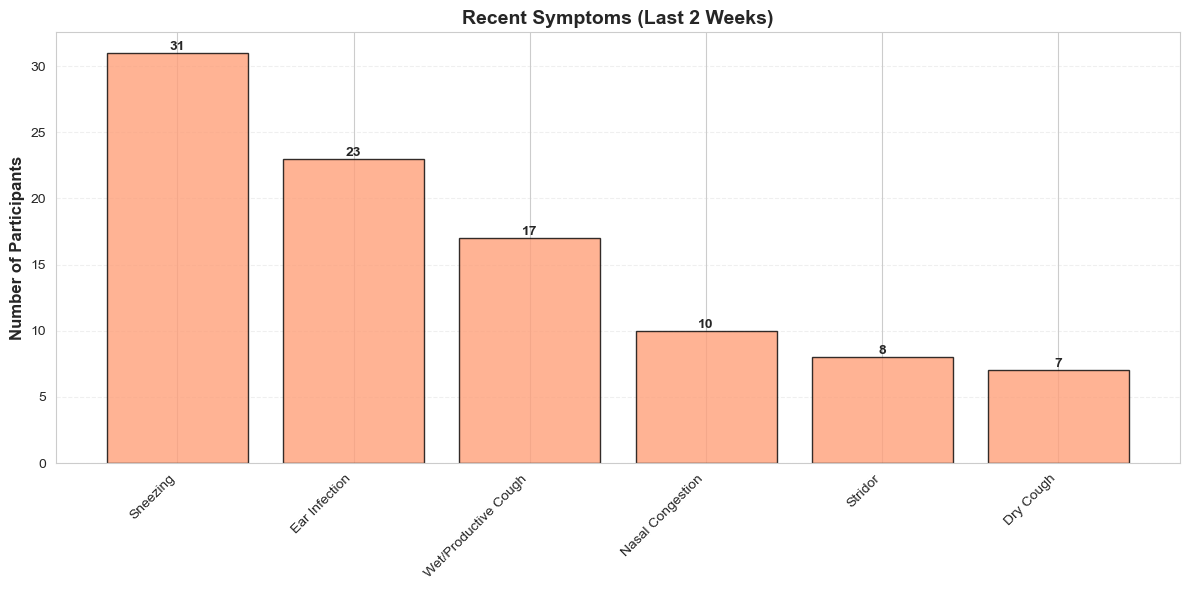

In [8]:
# Parse recent symptoms (multi-select field)
recent_symptoms = []
for val in df['peds_mc_l2w'].dropna():
    if isinstance(val, str) and val.strip():
        recent_symptoms.extend([item.strip() for item in val.split(',')])

recent_counter = Counter(recent_symptoms)

if recent_counter:
    # Readable labels
    recent_labels = {
        'wheezing or trouble breathing': 'Wheezing/Trouble Breathing',
        'dry cough': 'Dry Cough',
        'wet productive cough': 'Wet/Productive Cough',
        'nasal congestion': 'Nasal Congestion',
        'sneezing': 'Sneezing',
        'ear infection': 'Ear Infection',
        'stridor': 'Stridor',
        'croup': 'Croup',
        'sorethroat or tonsillitis': 'Sore Throat/Tonsillitis'
    }
    
    recent_data = [(recent_labels.get(k, k.title()), v) for k, v in recent_counter.most_common()]
    recent_data = sorted(recent_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_r = [item[0] for item in recent_data]
    counts_r = [item[1] for item in recent_data]
    
    bars = plt.bar(range(len(labels_r)), counts_r, color='lightsalmon', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_r)), labels_r, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Recent Symptoms (Last 2 Weeks)', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_r):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No recent symptoms data found")

## Summary Statistics

In [9]:
print("="*60)
print("MEDICAL CONDITIONS SUMMARY")
print("="*60)
print(f"\nTotal participants with condition data: {df['participant_id'].nunique()}")
print(f"\nTop 5 Most Common Conditions:")
for i, (label, data) in enumerate(sorted_conditions[:5], 1):
    print(f"{i}. {label}: {data['count']} participants ({data['percentage']:.1f}%)")

if hearing_counter:
    print(f"\nMost Common Hearing Condition: {hearing_data[0][0]} ({hearing_data[0][1]} cases)")

if breathing_counter:
    print(f"Most Common Breathing Condition: {breathing_data[0][0]} ({breathing_data[0][1]} cases)")

if voice_counter:
    print(f"Most Common Voice Disorder: {voice_data[0][0]} ({voice_data[0][1]} cases)")

if sleep_counter:
    print(f"Most Common Sleep Symptom: {sleep_data[0][0]} ({sleep_data[0][1]} cases)")

print("\n" + "="*60)

MEDICAL CONDITIONS SUMMARY

Total participants with condition data: 300

Top 5 Most Common Conditions:
1. Hearing Loss/Hearing Aids: 111 participants (37.4%)
2. Ear Tube Placement: 77 participants (25.9%)
3. Previous Hospitalization: 74 participants (24.9%)
4. Speech Therapy: 72 participants (24.4%)
5. Allergies: 70 participants (23.6%)

Most Common Hearing Condition: Hearing Loss (66 cases)
Most Common Breathing Condition: Asthma (33 cases)
Most Common Voice Disorder: GERD (13 cases)
Most Common Sleep Symptom: Gasping for Air at Night (75 cases)

